<a href="https://colab.research.google.com/github/JozefSL/EIA/blob/main/extractPriceData2yAvg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re
import os # Import the os module for file operations

url = 'https://www.eia.gov/outlooks/steo/outlook.php'

try:
    response = requests.get(url)
    response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)
    soup = BeautifulSoup(response.text, 'html.parser')

    print("Successfully fetched the webpage. Now looking for download links...")

    all_links = []
    for a_tag in soup.find_all('a', href=True):
        href = a_tag['href']
        # Resolve relative URLs to absolute URLs
        if not href.startswith('http'):
            href = requests.compat.urljoin(url, href)
        all_links.append(href)

    # Filter for historical forecast data files (ending in .xlsx or .xls and in archives)
    # and only keep files older than 2019.
    filtered_links = []
    for link in all_links:
        if 'archives' in link and (link.endswith('.xlsx') or link.endswith('.xls')):
            file_name = link.split('/')[-1]
            # Regex to find the two-digit year, e.g., 'sep25_base.xlsx' -> '25'
            match = re.search(r'[a-z]{3}(\d{2})_base\.(xlsx|xls)', file_name, re.IGNORECASE)
            if match:
                year_suffix = int(match.group(1))
                # We want files older than 2019, which means year suffix > 19 (e.g., 08 for 2008, 18 for 2018)
                if year_suffix > 19:
                    filtered_links.append(link)

    # Sort in reverse to process newest first, assuming this is desired for initial inspection
    historical_data_links = sorted(filtered_links, reverse=True)

    if historical_data_links:
        print(f"Found {len(historical_data_links)} potential historical forecast data links in archives (older than 2019).")
        print("Downloading and processing files...")

        all_extracted_rows = []

        for link_idx, link in enumerate(historical_data_links):
            file_name = link.split('/')[-1]
            print(f"({link_idx + 1}/{len(historical_data_links)}) Attempting to download {file_name} from: {link}")

            try:
                file_response = requests.get(link, stream=True)
                file_response.raise_for_status()

                with open(file_name, 'wb') as f:
                    for chunk in file_response.iter_content(chunk_size=8192):
                        f.write(chunk)
                print(f"Successfully downloaded {file_name}")

                # Read the '2tab' sheet into a pandas DataFrame without headers
                if file_name.endswith('.xlsx') or file_name.endswith('.xls'):
                    try:
                        df_raw = pd.read_excel(file_name, sheet_name='2tab', header=None)

                        # Extract relevant rows (0-indexed)
                        year_row = df_raw.iloc[2] # Row 3 in Excel
                        month_row = df_raw.iloc[3] # Row 4 in Excel
                        wti_data_row = df_raw.iloc[5] # Row 6 for WTI

                        # Custom logic to find the HH data row:
                        nghhuus_row_df = df_raw[df_raw[0] == 'NGHHUUS']
                        if not nghhuus_row_df.empty:
                            hh_data_row = nghhuus_row_df.iloc[0] # Use the found row
                            print(f"Found 'NGHHUUS' in {file_name}. Extracting HH data from this row.")
                        else:
                            hh_data_row = df_raw.iloc[25] # Fallback to original row 26 (index 25)
                            print(f"'NGHHUUS' not found in {file_name}. Falling back to row 26 (index 25) for HH data.")

                        current_year = None
                        # Iterate through columns starting from the third column (index 2)
                        # Assuming both WTI and HH rows have data for the same columns.
                        for col_idx in range(2, len(wti_data_row)):
                            # Update current_year from row 3, handling merged cells (NaNs)
                            if pd.notna(year_row[col_idx]):
                                try:
                                    current_year = int(year_row[col_idx])
                                except ValueError:
                                    current_year = None # Reset if not a valid year number

                            month = month_row[col_idx]
                            wti_value = wti_data_row[col_idx]
                            hh_value = hh_data_row[col_idx]

                            # Only append if we have valid year, month, WTI value and HH value
                            if (current_year is not None and pd.notna(month) and
                                pd.notna(wti_value) and pd.notna(hh_value)):
                                all_extracted_rows.append({
                                    'Year': current_year,
                                    'Month': month,
                                    'WTI': wti_value,
                                    'HH': hh_value,
                                    'Source_File': file_name
                                })
                        print(f"Successfully extracted WTI and HH data from {file_name}.")

                    except ValueError as ve:
                        print(f"Sheet '2tab' not found or other parsing error in {file_name}: {ve}")
                    except Exception as e:
                        print(f"Error reading Excel file {file_name} (sheet '2tab'): {e}")

                # Clean up the downloaded file after processing
                os.remove(file_name)
                print(f"Removed temporary file: {file_name}")

            except requests.exceptions.RequestException as e:
                print(f"Error downloading {file_name} from {link}: {e}")
            except Exception as e:
                print(f"An unexpected error occurred while processing {file_name}: {e}")

        if all_extracted_rows:
            print("\nConcatenating all extracted data into a final DataFrame...")
            final_df = pd.DataFrame(all_extracted_rows)
            print("Concatenation complete. Head of the final DataFrame:")
            print(final_df.head())
            print(f"Total rows in the combined DataFrame: {len(final_df)}")
        else:
            print("No data from '2tab' sheets could be read and concatenated.")

    else:
        print("No direct historical forecast data files (.xls, .xlsx) found in archives (older than 2019).")

except requests.exceptions.RequestException as e:
    print(f"Error fetching the URL or general request error: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Successfully fetched the webpage. Now looking for download links...
Found 81 potential historical forecast data links in archives (older than 2019).
(1/81) Attempting to download sep26_base.xlsx from: https://www.eia.gov/outlooks/steo/archives/sep26_base.xlsx
Successfully downloaded sep26_base.xlsx
Found 'NGHHUUS' in sep26_base.xlsx. Extracting HH data from this row.
Successfully extracted WTI and HH data from sep26_base.xlsx.
Removed temporary file: sep26_base.xlsx
(2/81) Attempting to download sep25_base.xlsx from: https://www.eia.gov/outlooks/steo/archives/sep25_base.xlsx
Successfully downloaded sep25_base.xlsx
Found 'NGHHUUS' in sep25_base.xlsx. Extracting HH data from this row.
Successfully extracted WTI and HH data from sep25_base.xlsx.
Removed temporary file: sep25_base.xlsx
(3/81) Attempting to download sep24_base.xlsx from: https://www.eia.gov/outlooks/steo/archives/sep24_base.xlsx
Successfully downloaded sep24_base.xlsx
Found 'NGHHUUS' in sep24_base.xlsx. Extracting HH data f

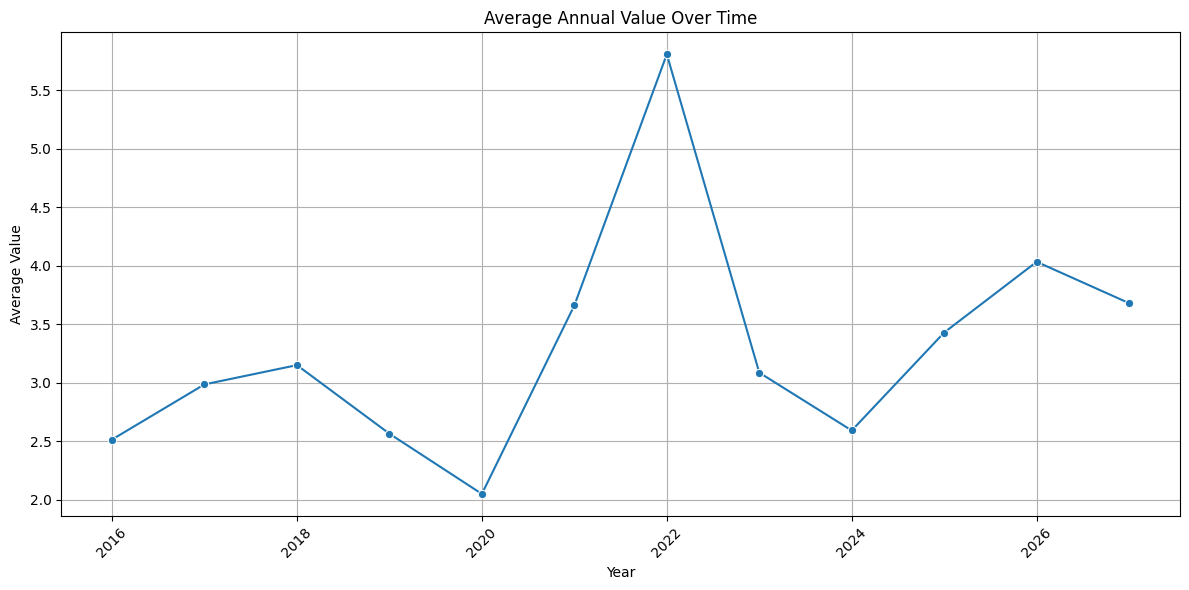

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average annual 'Value'
annual_avg_value = final_df.groupby('Year')['HH'].mean().reset_index()

# Plotting the average annual 'Value'
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='HH', data=annual_avg_value, marker='o')
plt.title('Average Annual Value Over Time')
plt.xlabel('Year')
plt.ylabel('Average Value')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
final_df.head()

,Year,Month,WTI,HH,Source_File
0,2022,Jan,83.22,4.38,sep26_base.xlsx
1,2022,Feb,91.64,4.69,sep26_base.xlsx
2,2022,Mar,108.50,4.90,sep26_base.xlsx
3,2022,Apr,101.78,6.60,sep26_base.xlsx
4,2022,May,109.55,8.14,sep26_base.xlsx


In [25]:
annual_df = final_df.groupby(['Source_File', 'Year'])[['HH','WTI']].mean().reset_index()
annual_df['HH2yAvg'] = annual_df.groupby('Source_File')['HH'].rolling(window=2, min_periods=1).mean().reset_index(level=0, drop=True)
annual_df['WTI2yAvg'] = annual_df.groupby('Source_File')['WTI'].rolling(window=2, min_periods=1).mean().reset_index(level=0, drop=True)

In [26]:
annual_df.head()

,Source_File,Year,HH,WTI,HH2yAvg,WTI2yAvg
0,apr20_base.xlsx,2016,2.514917,43.144917,2.514917,43.144917
1,apr20_base.xlsx,2017,2.986500,50.883417,2.750708,47.014167
2,apr20_base.xlsx,2018,3.151083,64.938250,3.068792,57.910833
3,apr20_base.xlsx,2019,2.565083,56.983333,2.858083,60.960792
4,apr20_base.xlsx,2020,2.113349,29.612308,2.339216,43.297821
